In [11]:
import pandas as pd


In [12]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df

,ds,Airports,Class,y
0,1989-07-10,ADL-PER,Business,193
1,1989-07-17,ADL-PER,Business,254
2,1989-07-24,ADL-PER,Business,185
3,1989-07-31,ADL-PER,Business,254
4,1989-08-07,ADL-PER,Business,191
...,...,...,...,...
7402,1992-10-19,SYD-PER,First,203
7403,1992-10-26,SYD-PER,First,137
7404,1992-11-02,SYD-PER,First,161
7405,1992-11-09,SYD-PER,First,155


## 3 way to change column type 
### first way:


In [13]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv", parse_dates=["ds"])
print(df["ds"].dtype)

datetime64[ns]


### second way:

In [14]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df_test["ds"] = pd.to_datetime(df_test["ds"] , format = "%Y-%M-%d")
print(df_test["ds"].dtype)

datetime64[ns]


### third way: custom parser

In [15]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"] , date_format = "%Y-%m-%d")
print(df_test["ds"].dtype)

datetime64[ns]


In [18]:
melsyd_economy = (
    pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
).reset_index()
melsyd_economy

,index,ds,unique_id,Class,y
0,3881,1987-06-22,MEL-SYD,Economy,20.167
1,3882,1987-06-29,MEL-SYD,Economy,20.161
2,3883,1987-07-06,MEL-SYD,Economy,19.993
3,3884,1987-07-13,MEL-SYD,Economy,20.986
4,3885,1987-07-20,MEL-SYD,Economy,20.497
...,...,...,...,...,...
277,4158,1992-10-19,MEL-SYD,Economy,28.837
278,4159,1992-10-26,MEL-SYD,Economy,26.548
279,4160,1992-11-02,MEL-SYD,Economy,27.279
280,4161,1992-11-09,MEL-SYD,Economy,27.306


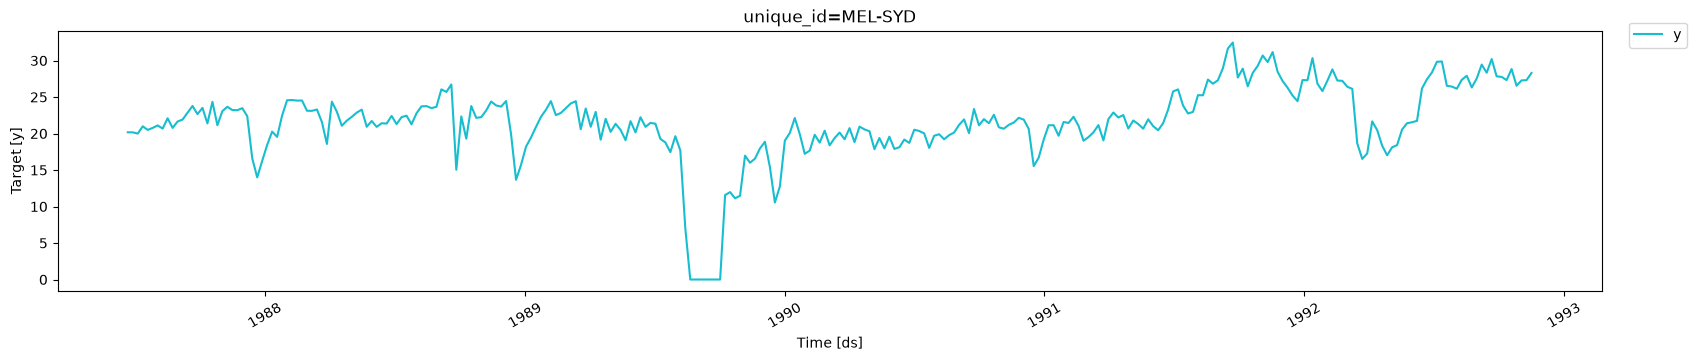

In [17]:
from utilsforecast.plotting import plot_series

plot_series(
    df = melsyd_economy,
    id_col = "unique_id",
    time_col = "ds",
    target_col = "y")

